In [5]:
import os
import copy
import torch
from pathlib import Path
from stMVCL.stMVCL.config import set_arg
from stMVCL.stMVCL.data import *
from stMVCL.stMVCL.utils import *
from stMVCL.stMVCL.stMVCL import *
import matplotlib.pyplot as plt
import scanpy as sc
import squidpy as sq
import matplotlib.pyplot as plt
from sklearn.metrics.cluster import adjusted_rand_score
from sklearn.metrics import normalized_mutual_info_score
from sklearn.metrics import homogeneity_score, completeness_score


In [6]:
os.environ['R_HOME'] = '/home/ZHX/anaconda3/envs/GraphST/lib/R'
current_path = os.getcwd()
print("当前路径：", current_path)
file_path=current_path
# gpu
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
# path
data_root = Path('/home/ZHX/Dataset/Human_Breast_Cancer')
result_path = "/home/ZHX/code111/GraphST-main/final_result/stMVCL_result/"
#设置参数
opt = set_arg()
arg = opt.parse_args(['--n_domain', '20','--radius', '300','--n_refine','70','--latent_dim','20','--seed','0'])
print(arg)

当前路径： /home/ZHX/code111/GraphST-main/stMVCL/Tutorial
Namespace(epoch=1000, hvg_n=3000, knn=6, latent_dim=20, log_step=10, lr=0.001, n_domain=20, n_refine=70, radius=300, seed=0, temp=0.05, weight_decay=0.0001)


/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


=============原始HBC切片信息，带ground truth===============
AnnData object with n_obs × n_vars = 3798 × 36601
    obs: 'in_tissue', 'array_row', 'array_col', 'slice_id', 'Ground Truth'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'


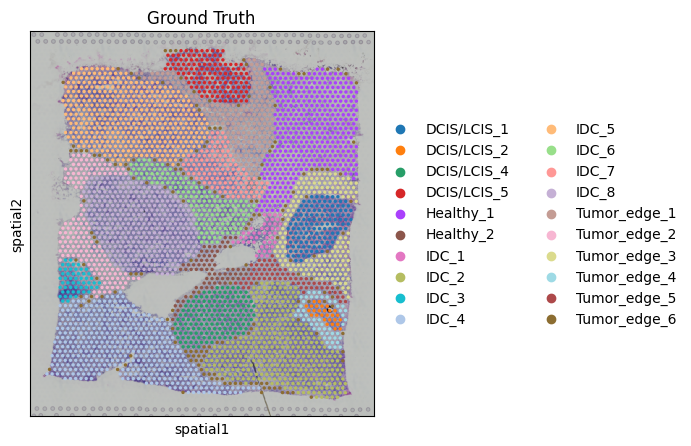

=============预处理后HBC切片信息===============
AnnData object with n_obs × n_vars = 3798 × 36601
    obs: 'in_tissue', 'array_row', 'array_col', 'slice_id', 'Ground Truth'
    var: 'gene_ids', 'feature_types', 'genome', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'spatial', 'Ground Truth_colors', 'hvg', 'log1p'
    obsm: 'spatial'
spatial graph(k) completed!
spatial graph(radius) completed!
start construct feature graph
feature graph completed!
Size of Input:  (3798, 3000)
AnnData object with n_obs × n_vars = 3798 × 36601
    obs: 'in_tissue', 'array_row', 'array_col', 'slice_id', 'Ground Truth'
    var: 'gene_ids', 'feature_types', 'genome', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'spatial', 'Ground Truth_colors', 'hvg', 'log1p'
    obsm: 'spatial', 'graph_neigh1', 'graph_neigh2', 'adj1', 'adj2', 'feat', 'feat_a', 'f_graph_neigh', 'fadj'
Begin to train ST data...


  0%|          | 5/1000 [00:00<00:23, 43.02it/s]

EP[   0]: rec_loss=3.0823.


 10%|█         | 105/1000 [00:02<00:21, 41.30it/s]

EP[ 100]: rec_loss=0.3236.


...

 80%|████████  | 805/1000 [00:19<00:04, 41.77it/s]

EP[ 800]: rec_loss=0.1183.


 90%|█████████ | 905/1000 [00:21<00:02, 41.70it/s]

EP[ 900]: rec_loss=0.1128.


100%|██████████| 1000/1000 [00:24<00:00, 41.49it/s]


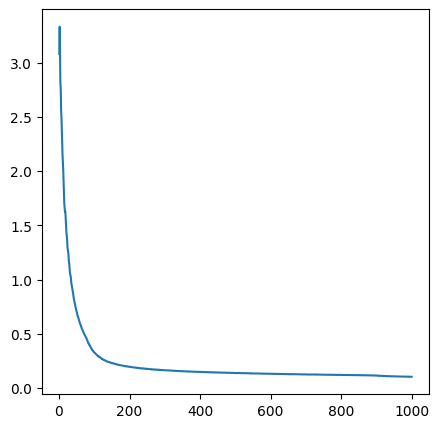

Completion of training
fitting ...
  |======================================================================| 100%


/tmp/ipykernel_3784154/1584695897.py:39: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns['ARI']=ARI


ARI = 0.5738
NMI = 0.7220
HS = 0.7330
CS = 0.7112


In [7]:
sample_name = 'HBC'
adata = read_data(data_root, sample_name)
## add ground truth
df_meta = pd.read_csv(data_root / sample_name / 'metadata.tsv', sep='\t', header=0, index_col=0)
adata.obs['Ground Truth'] = df_meta.loc[adata.obs_names, 'ground_truth']
# adata_list_raw.append(copy.deepcopy(adata)) ## 创建一个adata的深层副本并添加到列表中
print("=============原始{}切片信息，带ground truth===============".format(sample_name))
print(adata)
plt.rcParams["figure.figsize"] = (5, 5)
sc.pl.spatial(adata, img_key="hires", color=["Ground Truth"])

#preprocessing
sc.pp.highly_variable_genes(adata, flavor="seurat_v3", n_top_genes=3000)
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
# sc.pp.scale(adata)
print("=============预处理后{}切片信息===============".format(sample_name))
print(adata)

# # Plot ground truth
# plt.rcParams["figure.figsize"] = (3, 3)
# sc.pl.spatial(adata, img_key="hires", color=["Ground Truth"],show=False)

# train model
adata = train(adata,arg)
print("Completion of training")

# clustering
# adata = mclust_R(adata, arg.n_domain,used_obsm='MVInfoNCE' )
adata = mclust_R(adata, arg.n_domain,used_obsm='stMVCL' ,refine=True, n_refine=arg.n_refine)

# filter out NA nodes
adata = adata[~pd.isnull(adata.obs['Ground Truth'])]
ARI = adjusted_rand_score(adata.obs['mclust'], adata.obs['Ground Truth'])
NMI = normalized_mutual_info_score(adata.obs['mclust'], adata.obs['Ground Truth'])
HS = homogeneity_score(adata.obs['Ground Truth'],adata.obs['mclust'])
CS = completeness_score(adata.obs['Ground Truth'],adata.obs['mclust'])

adata.uns['ARI']=ARI
adata.uns['NMI']=NMI
adata.uns['HS']=HS
adata.uns['CS']=CS
print('ARI = %.4f' %ARI)
print('NMI = %.4f' %NMI)
print('HS = %.4f' %HS)
print('CS = %.4f' %CS)



/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/tools/_paga.py:121: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns['paga'] = {}


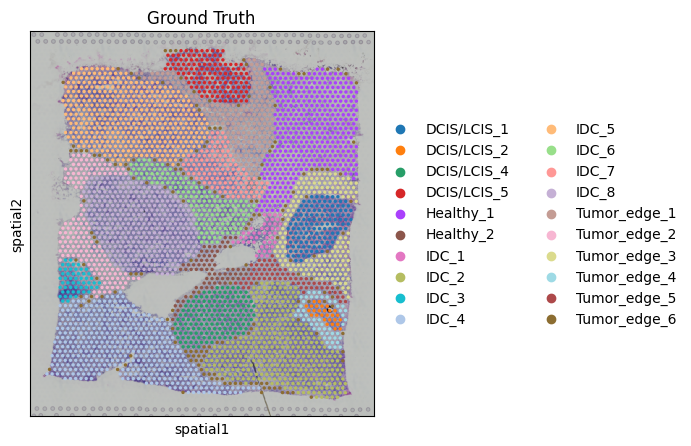

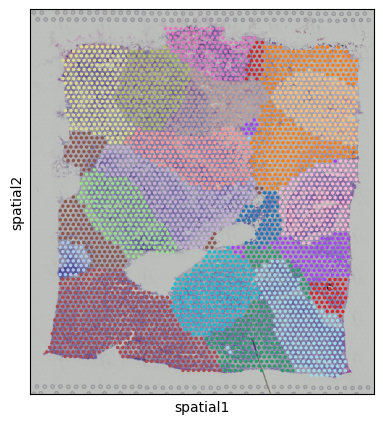

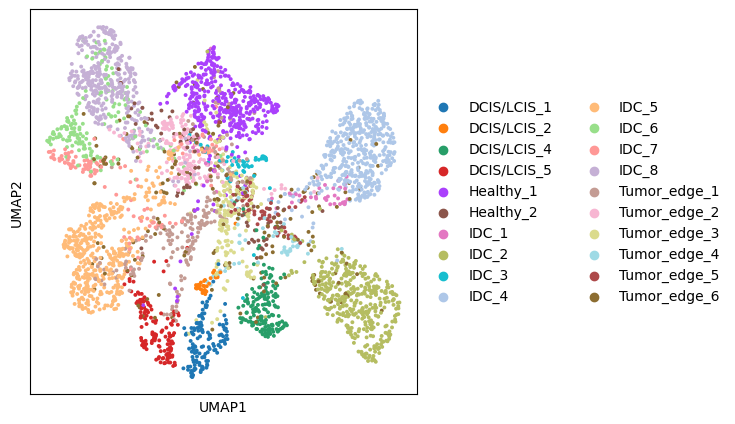

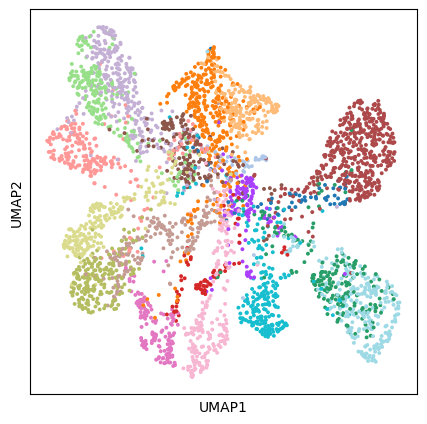

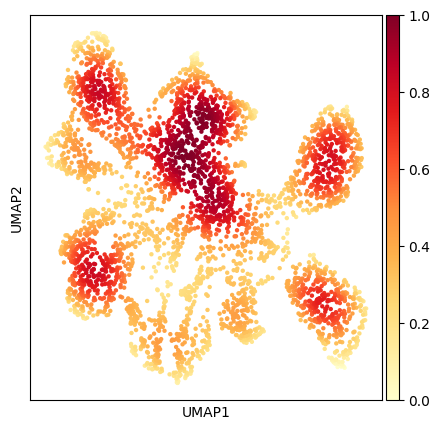

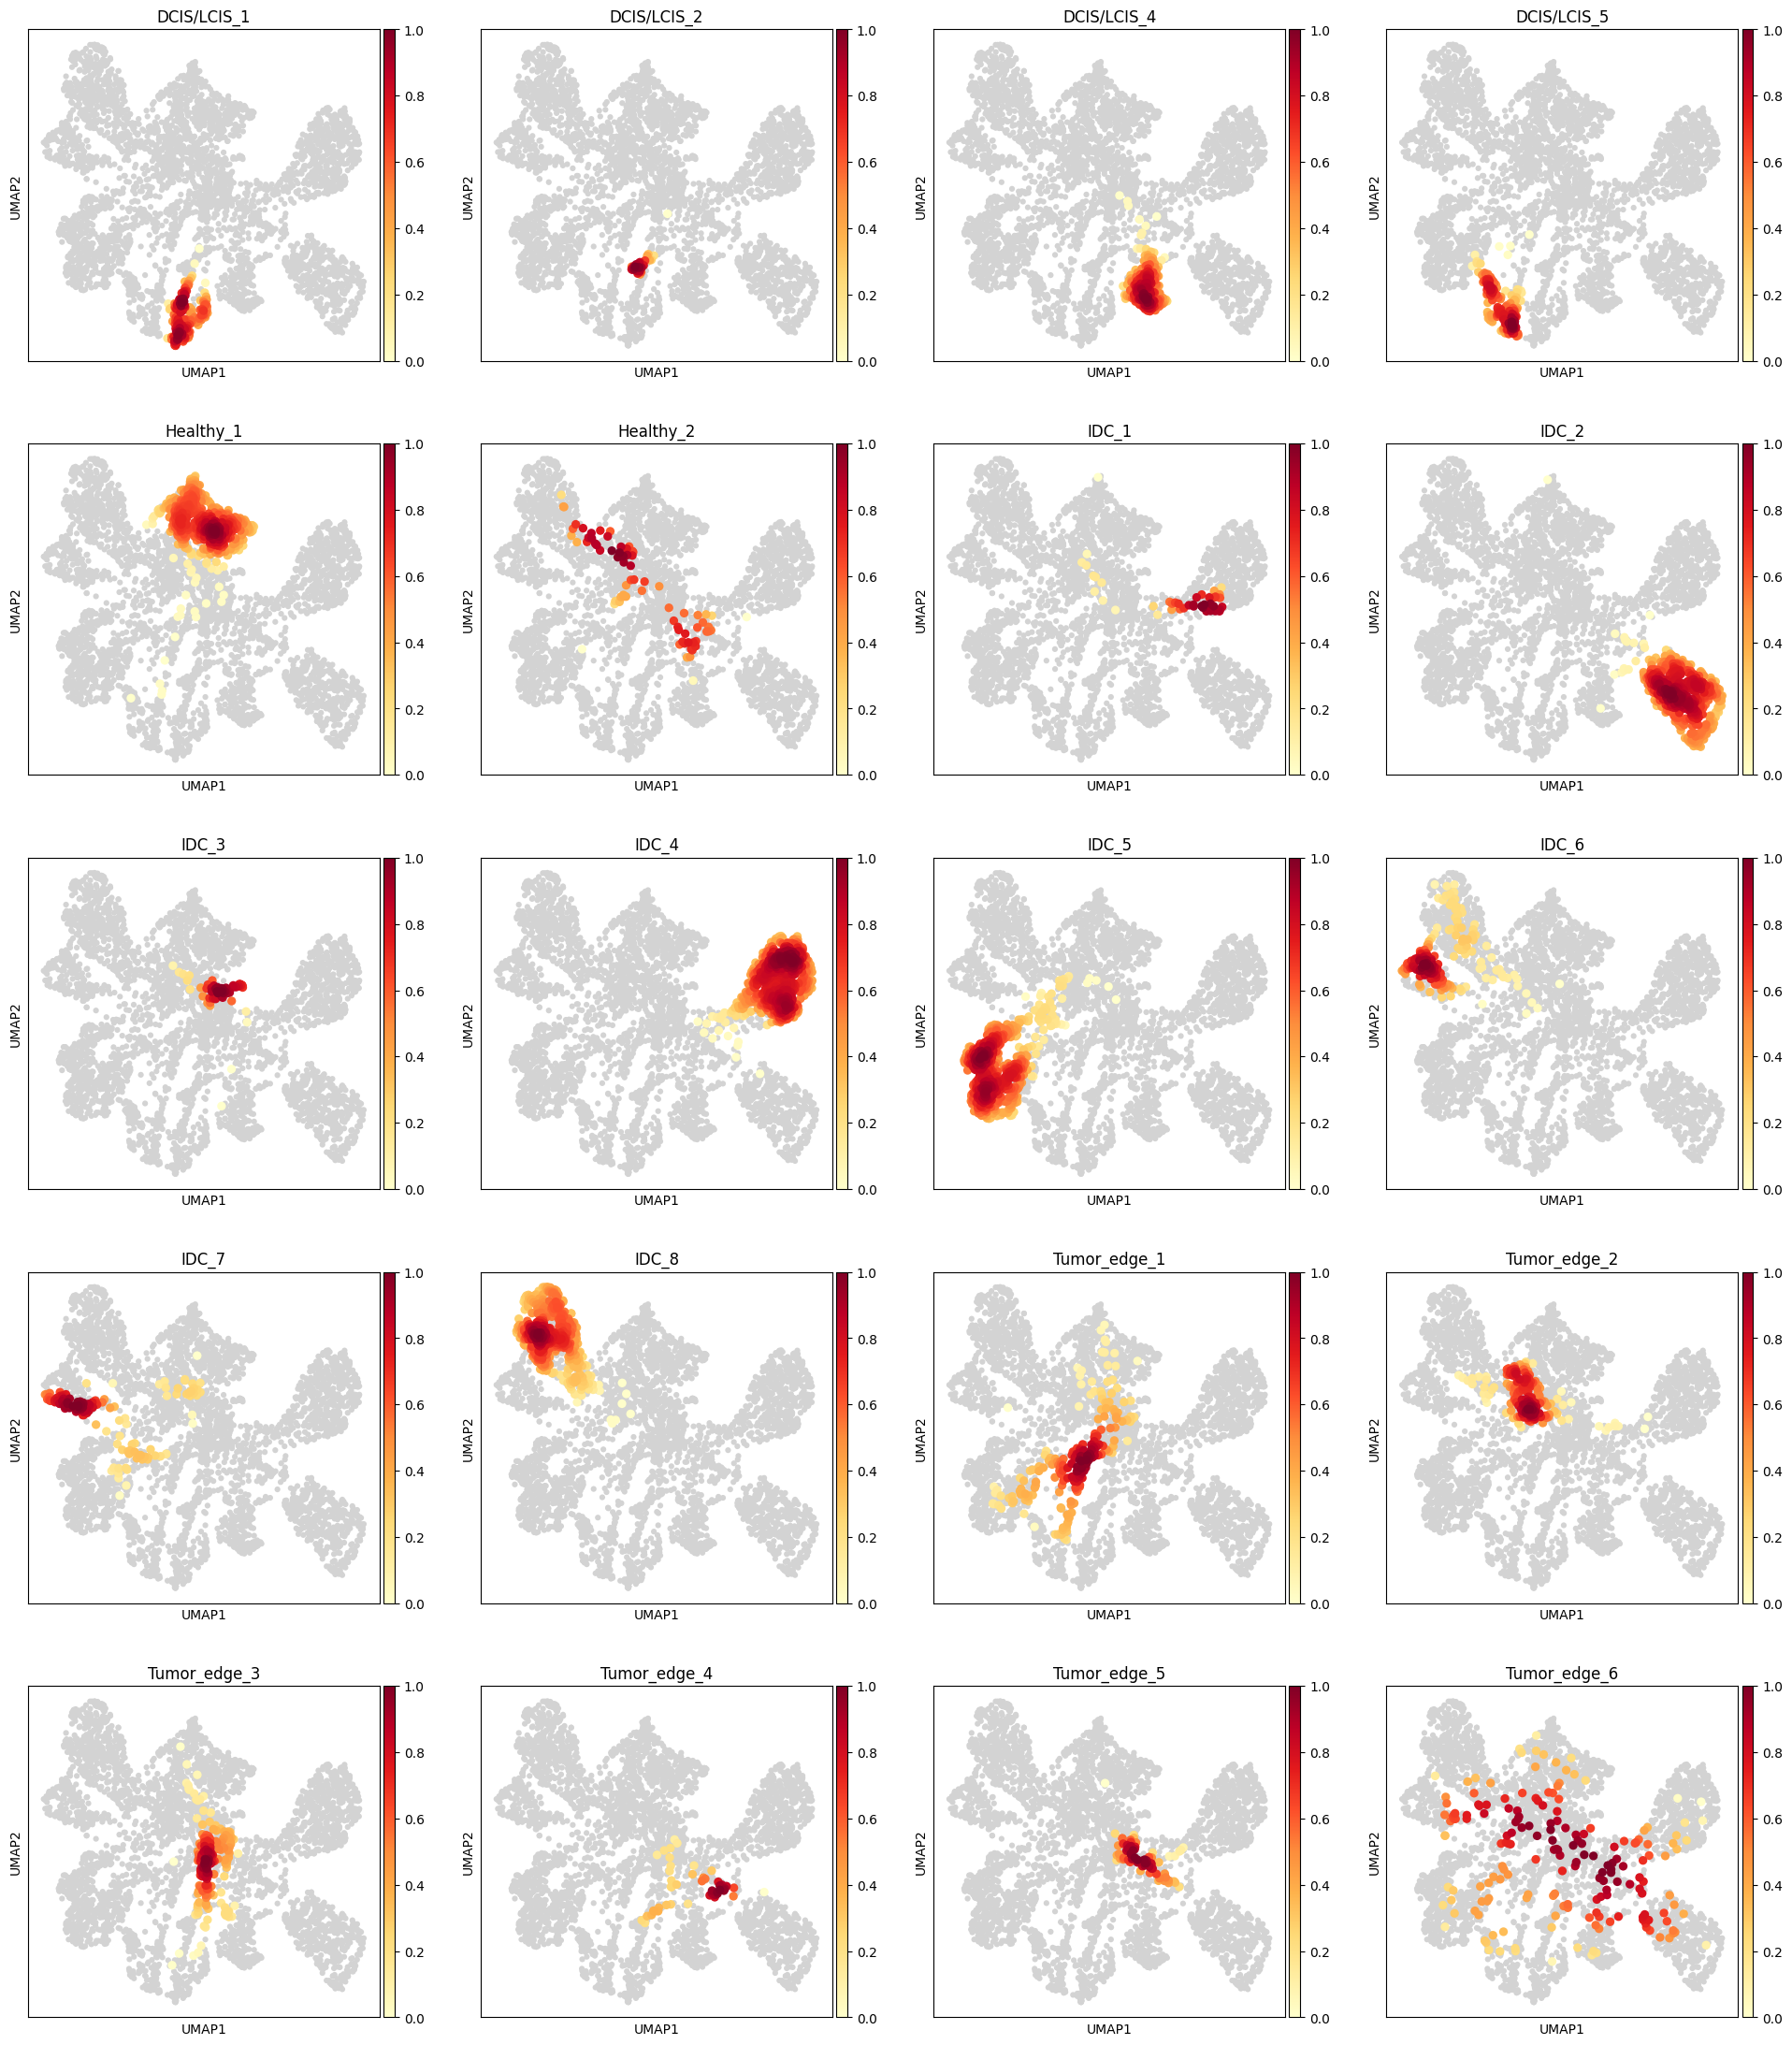

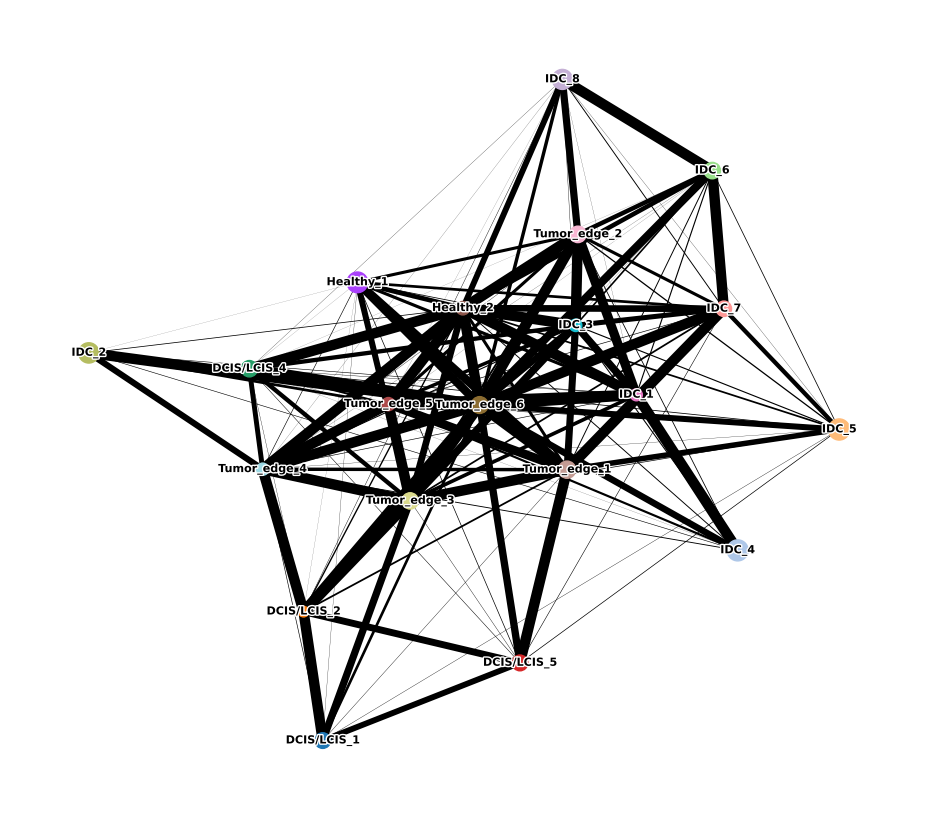

In [8]:
out_path = os.path.join(result_path , sample_name)
# 检查文件夹是否存在，如果不存在则创建文件夹
if not os.path.exists(out_path):
    os.makedirs(out_path)

## spatial architectures
plt.rcParams["figure.figsize"] = (5, 5)
sc.pl.spatial(adata,
                  img_key="hires",
                  color="Ground Truth",
                  show=False)
plt.savefig(os.path.join(out_path,"{}_ground truth.png").format(sample_name),bbox_inches='tight',dpi=300)

plt.rcParams["figure.figsize"] = (5, 5)
sc.pl.spatial(adata,
                  img_key="hires",
                  color="mclust",
                  title='',
                  legend_loc='none',
                  show=False)
plt.savefig(os.path.join(out_path,"{}_ARI.png").format(sample_name))


# plotting predicted labels by UMAP
sc.pp.neighbors(adata, use_rep='stMVCL')
sc.tl.umap(adata)
plt.rcParams["figure.figsize"] = (5, 5)
sc.pl.umap(adata,
               color="Ground Truth",
               title='',
               show=False)
plt.savefig(os.path.join(out_path,"{}_ground_truth_umap.png").format(sample_name),bbox_inches='tight',dpi=300)

plt.rcParams["figure.figsize"] = (5, 5)
sc.pl.umap(adata,
               color="mclust",
                title='',
               legend_loc='none',
               show=False)
plt.savefig(os.path.join(out_path,"{}_umap.png").format(sample_name))


## heatmap of density
plt.rcParams["figure.figsize"] = (5, 5)
sc.tl.embedding_density(adata, basis='umap')
sc.pl.embedding_density(adata, basis='umap', fg_dotsize=40, show=False)
plt.savefig(os.path.join(out_path,"{}_heatmap of density.png").format(sample_name))

plt.rcParams["figure.figsize"] = (5, 5)
sc.tl.embedding_density(adata, basis='umap', groupby='Ground Truth')
sc.pl.embedding_density(adata, basis='umap', groupby='Ground Truth', show=False)
plt.savefig(os.path.join(out_path,"{}_heatmap of density_by_layer.png").format(sample_name))

## paga trajectory inference
adata = adata[adata.obs['Ground Truth'].notna(), :]
sc.tl.paga(adata, groups='Ground Truth')
plt.rcParams["figure.figsize"] = (10, 10)
# 绘制标准PAGA图 (替换了paga_compare)
sc.pl.paga(adata,show=False,  frameon=False, fontoutline=2, fontsize=8)
plt.savefig(os.path.join(out_path,"{}_paga.png").format(sample_name),bbox_inches='tight',dpi=300)

# plt.rcParams["figure.figsize"] = (5, 5)
# # 绘制标准PAGA图 (替换了paga_compare)
# sc.pl.paga(adata,show=False, fontsize=10,  fontoutline=2)
# plt.savefig(os.path.join(out_path,"{}_paga_frame.png").format(sample_name),bbox_inches='tight',dpi=300)

# ## paga trajectory inference
# adata = adata[adata.obs['Ground Truth'].notna(), :]
# sc.tl.paga(adata, groups='Ground Truth')
# plt.rcParams["figure.figsize"] = (5, 5)
# sc.pl.paga_compare(adata, legend_fontsize=10, frameon=False, size=50,
#                    title=adata.obs['slice_id'].unique()[0] + '-stMVCL', legend_fontoutline=2, show=False)
# plt.savefig(os.path.join(out_path,"{}_paga.png").format(adata.obs['slice_id'].unique()[0]))
